<a href="https://colab.research.google.com/github/IrisFDTD/AI-UNIZAR-course/blob/main/eot/ai_unizar_course_scattering_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Licencia Creative Commons" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">*Introducción a la inteligencia artificial: redes neuronales avanzadas con Tensorflow-Keras*</span> por <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">Sergio Gutiérrez Rodrigo (sergut@unizar.es)</span> se distribuye bajo una <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Licencia Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional</a>.

```
Sergio G Rodrigo
Departamento de Física Aplicada
Universidad de Zaragoza
Instituto de Nanociencia y Materiales de Aragón (INMA)
C/ Pedro Cerbuna, 12, 50009, Zaragoza, España
```






# **Advanced Neural Networks with TensorFlow-Keras**

---
# **Replace numerical methods with neural networks (numerical method surrogate): The Fano model**

https://en.wikipedia.org/wiki/Fano_resonance
---


# Main imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
import keras as keras
from keras import models,layers,utils
from keras.models import Sequential
from keras.layers import Input,Dense
from keras.optimizers import SGD, Adam

# Auxiliary functions

In [ ]:
def plot_history(history):
    train_loss = history.history['loss']
    epochs = range(1, len(train_loss) + 1)

    # Extract the validation loss values
    val_loss = history.history['val_loss']

    # Plot the training loss and validation loss vs. epoch
    plt.rcParams.update({'font.size': 14})
    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    pass

# Fano model (with the help of Gemini)


$T=\dfrac{(q+\varepsilon)^2}{(1+\varepsilon^2)}$
where
$\varepsilon=\dfrac{E-E_{res}}{\Gamma/2}$

**Prompt:**
*A fano model is a physical model which accounts for scattering properties in many physical systems involving waves. Could you build the simplest fano model function possible and give a case of use?*

**Answer:** Here's the simplest Fano model function possible, defined in Python. This function calculates the transmittance (T) based on the input energy, Fano asymmetry parameter (q), resonance energy (E_res), and resonance width (Gamma).

Now that the fano_model function is defined, let's plot an example of a Fano resonance curve using some typical parameters. This will help you visualize how the model behaves.

The Fano model function was successfully used to calculate and plot the transmittance for a given set of parameters. The plot visually represents the Fano resonance phenomenon, showing how transmittance changes with energy (wavelength) around a specific resonance energy. The curve displays the characteristic asymmetric shape of a Fano resonance.

In [ ]:
def fano_model(energy, q, E_res, Gamma):
    """
    Calculates the Fano resonance transmittance.

    Args:
        energy (float or np.array): The energy (or frequency/wavelength) values.
        q (float): The Fano asymmetry parameter.
        E_res (float): The resonance energy.
        Gamma (float): The resonance width.

    Returns:
        float or np.array: The transmittance values according to the Fano model.

    # An alternative common form using epsilon the reduced energy (or detuning) parameter
    #epsilon = (energy - E_res) / (Gamma / 2)
    # transmittance = ((q + epsilon)**2) / (1 + epsilon**2)
    """
    # Fano formula for transmittance
    transmittance = ((q * Gamma / 2) + (energy - E_res))**2 / ((Gamma / 2)**2 + (energy - E_res)**2)

    return transmittance/np.max(transmittance)

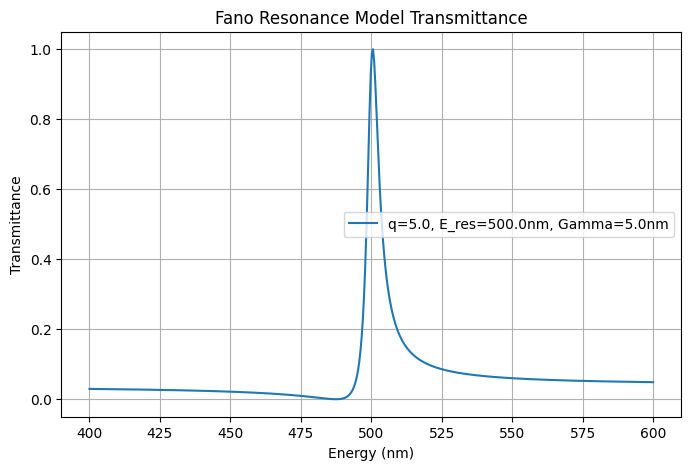

In [ ]:
# Example usage of the fano_model function

# Define example parameters
q_param = 5.0  # Fano asymmetry parameter
E_res_param = 500.0  # Resonance energy (e.g., wavelength in nm)
Gamma_param = 5.0  # Resonance width (e.g., wavelength in nm)

# Generate energy values (e.g., wavelengths)
energies = np.linspace(400, 600, 500) # From 400nm to 600nm with 500 points

# Calculate transmittance using the fano_model
transmittance_values = fano_model(energies, q_param, E_res_param, Gamma_param)

# Plot the Fano resonance curve
plt.figure(figsize=(8, 5))
plt.plot(energies, transmittance_values, label=f'q={q_param}, E_res={E_res_param}nm, Gamma={Gamma_param}nm')
plt.title('Fano Resonance Model Transmittance')
plt.xlabel('Energy (nm)')
plt.ylabel('Transmittance')
plt.grid(True)
plt.legend()
plt.show()

# Generate training data (Fano's spectra)

+  Each spectrum is calculated at 300 wavelengths from 400.0 nm to 1000.0 nm
+  The database contains N_spectra spectra.


**Prompt:** *Write a function to generate N_spectra training spectra based on the Fano model. The number of wavelenths must be called nwav. We'll take 300. The result must be a list. Each element of the list contains two "objets". The first one, the Fano model parameters. The second one, a numpy array with first column being wavelengths and second column the Fano model corresponding transmittance.*

In [ ]:
def generate_fano_spectra(N_spectra, nwav=300):
    """
    Generates N_spectra training spectra based on the Fano model with random parameters.

    Args:
        N_spectra (int): The number of spectra to generate.
        nwav (int): The number of wavelengths for each spectrum. Default is 300.

    Returns:
        list: A list where each element is a tuple.
              Each tuple contains:
              - A tuple of Fano model parameters (q, E_res, Gamma).
              - A numpy array with the first column being wavelengths and the second
                column being the Fano model corresponding transmittance.
    """
    generated_spectra = []

    # Wavelength range based on the existing dataset (400nm to 1000nm)
    min_wavelength = 400.0
    max_wavelength = 1000.0
    wavelengths = np.linspace(min_wavelength, max_wavelength, nwav)

    for _ in range(N_spectra):
        # Generate random Fano parameters within reasonable physical ranges
        q = np.random.uniform(0.0, 10.0)      # Fano asymmetry parameter
        # Resonance energy typically within the wavelength range, but not at the very edges
        E_res = np.random.uniform(min_wavelength + 50, max_wavelength - 50)
        # Resonance width
        Gamma = np.random.uniform(5.0, 100.0)

        # Calculate transmittance using the fano_model (assumes fano_model is defined and normalizes)
        transmittance_values = fano_model(wavelengths, q, E_res, Gamma)

        # Combine wavelengths and transmittance into a numpy array
        spectrum_array = np.column_stack((wavelengths, transmittance_values))

        # Store parameters and spectrum
        fano_params = (q, E_res, Gamma)
        generated_spectra.append((fano_params, spectrum_array))

    return generated_spectra

# Example usage of the newly defined function:
# Let's generate 5 Fano spectra and inspect the first one
N_SPECTRA_TO_GENERATE = 1000
fano_dataset = generate_fano_spectra(N_SPECTRA_TO_GENERATE)
print(len(fano_dataset))
print(f"Generated {len(fano_dataset)} Fano spectra.")
print("\nFirst spectrum details:")
print("Parameters (q, E_res, Gamma):", fano_dataset[0][0])
print("Spectrum array shape (wavelengths, transmittance):", fano_dataset[0][1].shape)
print("First 5 rows of spectrum array:\n", fano_dataset[0][1][:5])
print("Last 5 rows of spectrum array:\n", fano_dataset[0][1][-5:])

1000
Generated 1000 Fano spectra.

First spectrum details:
Parameters (q, E_res, Gamma): (7.075016443251382, 857.6067740654414, 67.99268732742476)
Spectrum array shape (wavelengths, transmittance): (300, 2)
First 5 rows of spectrum array:
 [[4.00000000e+02 4.38636277e-03]
 [4.02006689e+02 4.34344466e-03]
 [4.04013378e+02 4.30036179e-03]
 [4.06020067e+02 4.25711483e-03]
 [4.08026756e+02 4.21370454e-03]]
Last 5 rows of spectrum array:
 [[9.91973244e+02 1.43387946e-01]
 [9.93979933e+02 1.40941063e-01]
 [9.95986622e+02 1.38577964e-01]
 [9.97993311e+02 1.36294742e-01]
 [1.00000000e+03 1.34087718e-01]]


**Prompt:** With fano_dataset, create x_train (input of a neural network) and y_train (output of a neural network) with the following properties: 1) x_train is a vector containing the Fano parameters and the wavelength. 2) x_train should be normalized for maximum values of each of the dimensions. 3) y_train is the corresponding transmittance for x_train.

In [ ]:
# Assuming fano_dataset is already generated and available
# If not, run N_SPECTRA_TO_GENERATE = 1000 # For example
# fano_dataset = generate_fano_spectra(N_SPECTRA_TO_GENERATE)

# Initialize lists to store raw (unnormalized) data
x_data_raw = []
y_data = []

# Populate x_data_raw and y_data from fano_dataset
for fano_params, spectrum_array in fano_dataset:
    q, E_res, Gamma = fano_params
    wavelengths = spectrum_array[:, 0]  # First column is wavelengths
    transmittances = spectrum_array[:, 1] # Second column is transmittances

    for i in range(len(wavelengths)):
        # x_train is a vector containing the Fano parameters and the wavelength
        x_data_raw.append([q, E_res, Gamma, wavelengths[i]])
        # y_train is the corresponding transmittance
        y_data.append(transmittances[i])

# Convert to numpy arrays
x_data_raw = np.array(x_data_raw)
y_data = np.array(y_data)

# Normalize x_train for maximum values of each of the dimensions
# Find the maximum value for each column (dimension)
max_values = x_data_raw.max(axis=0);

# Check for zero max_values to avoid division by zero
# If a max_value is 0, it means all values in that column are 0, so we can keep them 0 or handle as needed.
# For physical parameters, they usually won't be all zero.
max_values[max_values == 0] = 1.0 # Replace 0 with 1 to prevent division by zero, assuming 0/1 is still 0.

x_data = x_data_raw / max_values

print("Max values (q,E_res,Gamma,wavelengths):",max_values)
print("Shape of x_data_raw:", x_data_raw.shape)
print("Shape of x_data (normalized input):\n", x_data.shape)
print("First 5 rows of x_data (normalized input):\n", x_data[:5])
print("Shape of y_data (output):\n", y_data.shape)
print("First 5 values of y_data (output):\n", y_data[:5])

Shape of x_data_raw: (300000, 4)
Shape of x_data (normalized input):
 (300000, 4)
First 5 rows of x_data (normalized input):
 [[0.7096417  0.90275314 0.68021066 0.4       ]
 [0.7096417  0.90275314 0.68021066 0.40200669]
 [0.7096417  0.90275314 0.68021066 0.40401338]
 [0.7096417  0.90275314 0.68021066 0.40602007]
 [0.7096417  0.90275314 0.68021066 0.40802676]]
Shape of y_data (output):
 (300000,)
First 5 values of y_data (output):
 [0.00438636 0.00434344 0.00430036 0.00425711 0.0042137 ]


In [ ]:
# Set training and test data from the normalized dataset
# Function train_test_split() split & randomize data
x_train, x_val = train_test_split(x_data, test_size=0.1, random_state=42) #sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
y_train, y_val = train_test_split(y_data, test_size=0.1, random_state=42) #sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

# Define and run the neural network (sequential model)

In [ ]:
network_name='./model_1.keras'

In [ ]:
#hiperparameters
epochs  =		100
mini_batch_size= 64

In [ ]:
input_neurons=x_train.shape[1] # One neuron for each input parameter
output_neurons=1 # One neuron for value to predict

model=keras.models.Sequential()
model.add(Input((input_neurons,)))
model.add(layers.Dense(80, activation='sigmoid'))
model.add(layers.Dense(80, activation='sigmoid'))
model.add(layers.Dense(output_neurons, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 80)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,961 (27.19 KB)

 Trainable params: 6,961 (27.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam()
model.compile(optimizer=optimizer,loss='mse',metrics=['mse'])

In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=mini_batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))
model.save(network_name)

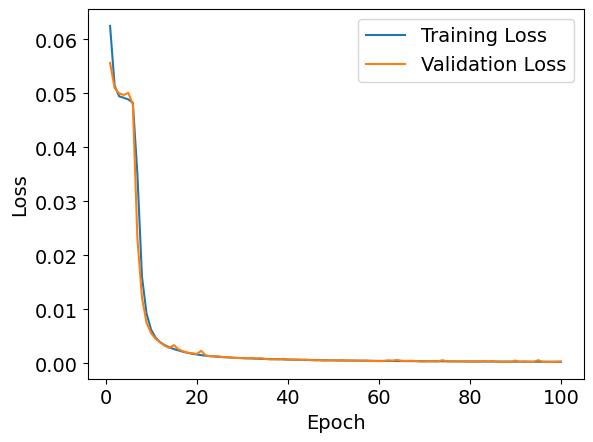

In [ ]:
plot_history(history)

## Results: neural network prediction against true values

./model_1.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 80)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,885 (81.59 KB)

 Trainable params: 6,961 (27.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,924 (54.39 KB)

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.8866e-04 - mse: 2.8866e-04
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


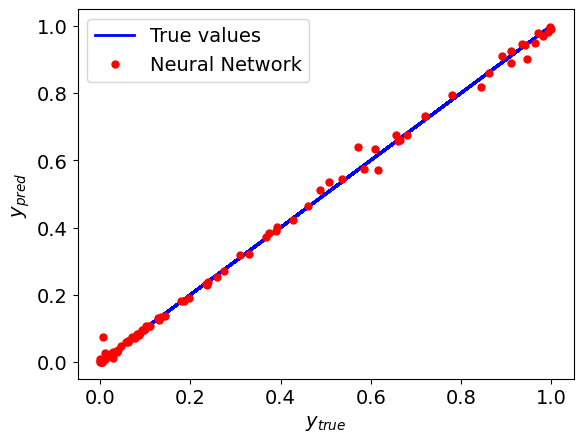

In [ ]:
model=models.load_model(network_name)
print(network_name)
model.summary()
score = model.evaluate(x_val, y_val, verbose=1)

# Check validation dataset with N random values
N=100
range_rnd=np.random.randint(0,len(x_val),size=(1,N))
y_pred=model.predict(x_val[range_rnd[0]])
y_true=y_val[range_rnd[0]]

# Plot true vs predicted
plt.plot(y_true,y_true, color="blue", fillstyle='none',linewidth=2, marker='.', markersize=0,label='True values')
plt.plot(y_true,y_pred, color="red", linewidth=0, marker='.', markersize=10,label='Neural Network')
plt.xlabel('$y_{true}$')
plt.ylabel('$y_{pred}$')
plt.legend()
plt.show()

## Visualize spectra: neural network prediction against true values

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


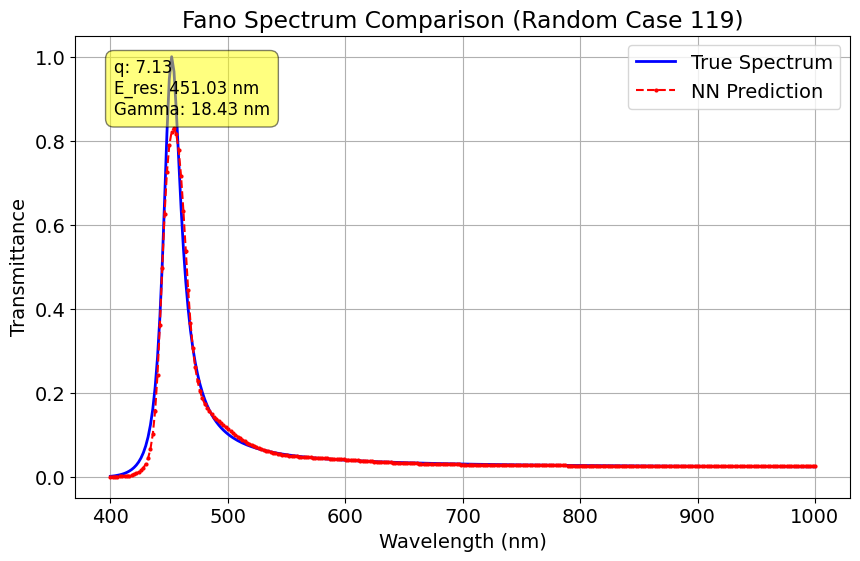

In [ ]:
# Select a random index from the fano_dataset
random_idx = np.random.randint(len(fano_dataset))

# Get the Fano parameters and spectrum for the chosen random case
fano_params_true, spectrum_array_true = fano_dataset[random_idx]
q_true, E_res_true, Gamma_true = fano_params_true
wavelengths_true = spectrum_array_true[:, 0]
transmittance_true = spectrum_array_true[:, 1]

# Prepare input for the neural network prediction
# Repeat Fano parameters for each wavelength in the spectrum
num_wavelengths = len(wavelengths_true)
q_input = np.full(num_wavelengths, q_true)
E_res_input = np.full(num_wavelengths, E_res_true)
Gamma_input = np.full(num_wavelengths, Gamma_true)

# Combine parameters and wavelengths into a raw input array
x_input_raw_single_spectrum = np.column_stack((
    q_input,
    E_res_input,
    Gamma_input,
    wavelengths_true
))

# Normalize the input using the max_values from the entire training dataset
# 'max_values' was computed when creating x_data (cell KuY1rArIBM3j)
x_input_normalized_single_spectrum = x_input_raw_single_spectrum / max_values

# Make a prediction using the trained model
transmittance_pred = model.predict(x_input_normalized_single_spectrum)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(wavelengths_true, transmittance_true, label='True Spectrum', color='blue', linewidth=2)
plt.plot(wavelengths_true, transmittance_pred, label='NN Prediction', color='red', linestyle='--', marker='.', markersize=4)

plt.title(f'Fano Spectrum Comparison (Random Case {random_idx})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmittance')
plt.legend()
plt.grid(True)

# Display Fano parameters on the figure
plt.text(0.05, 0.95, f'q: {q_true:.2f}\nE_res: {E_res_true:.2f} nm\nGamma: {Gamma_true:.2f} nm',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.show()

# Define and run the neural network (multi-input model)

In [ ]:
network_name_multiinput='./model_2.keras'

In [ ]:
#hiperparameters
epochs  =		30
mini_batch_size= 64

In [ ]:
# Input 1: geometrical parameters
input_geo=Input((3,))
x_geo=Dense(80, activation='sigmoid')(input_geo)
x_geo=Dense(80, activation='sigmoid')(x_geo)

# Input 2: wavelengtth
input_lambda=Input((1,))
x_lambda=Dense(20, activation='sigmoid')(input_lambda)

# Concatenate inputs
x=keras.layers.concatenate([x_geo,x_lambda])

# Last layer(s) and output
x=Dense(10, activation='sigmoid')(x)
output=Dense(1,activation='sigmoid')(x)

# Create the model
model=keras.Model([input_geo,input_lambda],output)

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 80)        │        320 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 80)        │      6,480 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20)        │         40 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      1,010 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         11 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,861 (30.71 KB)

 Trainable params: 7,861 (30.71 KB)

 Non-trainable params: 0 (0.00 B)

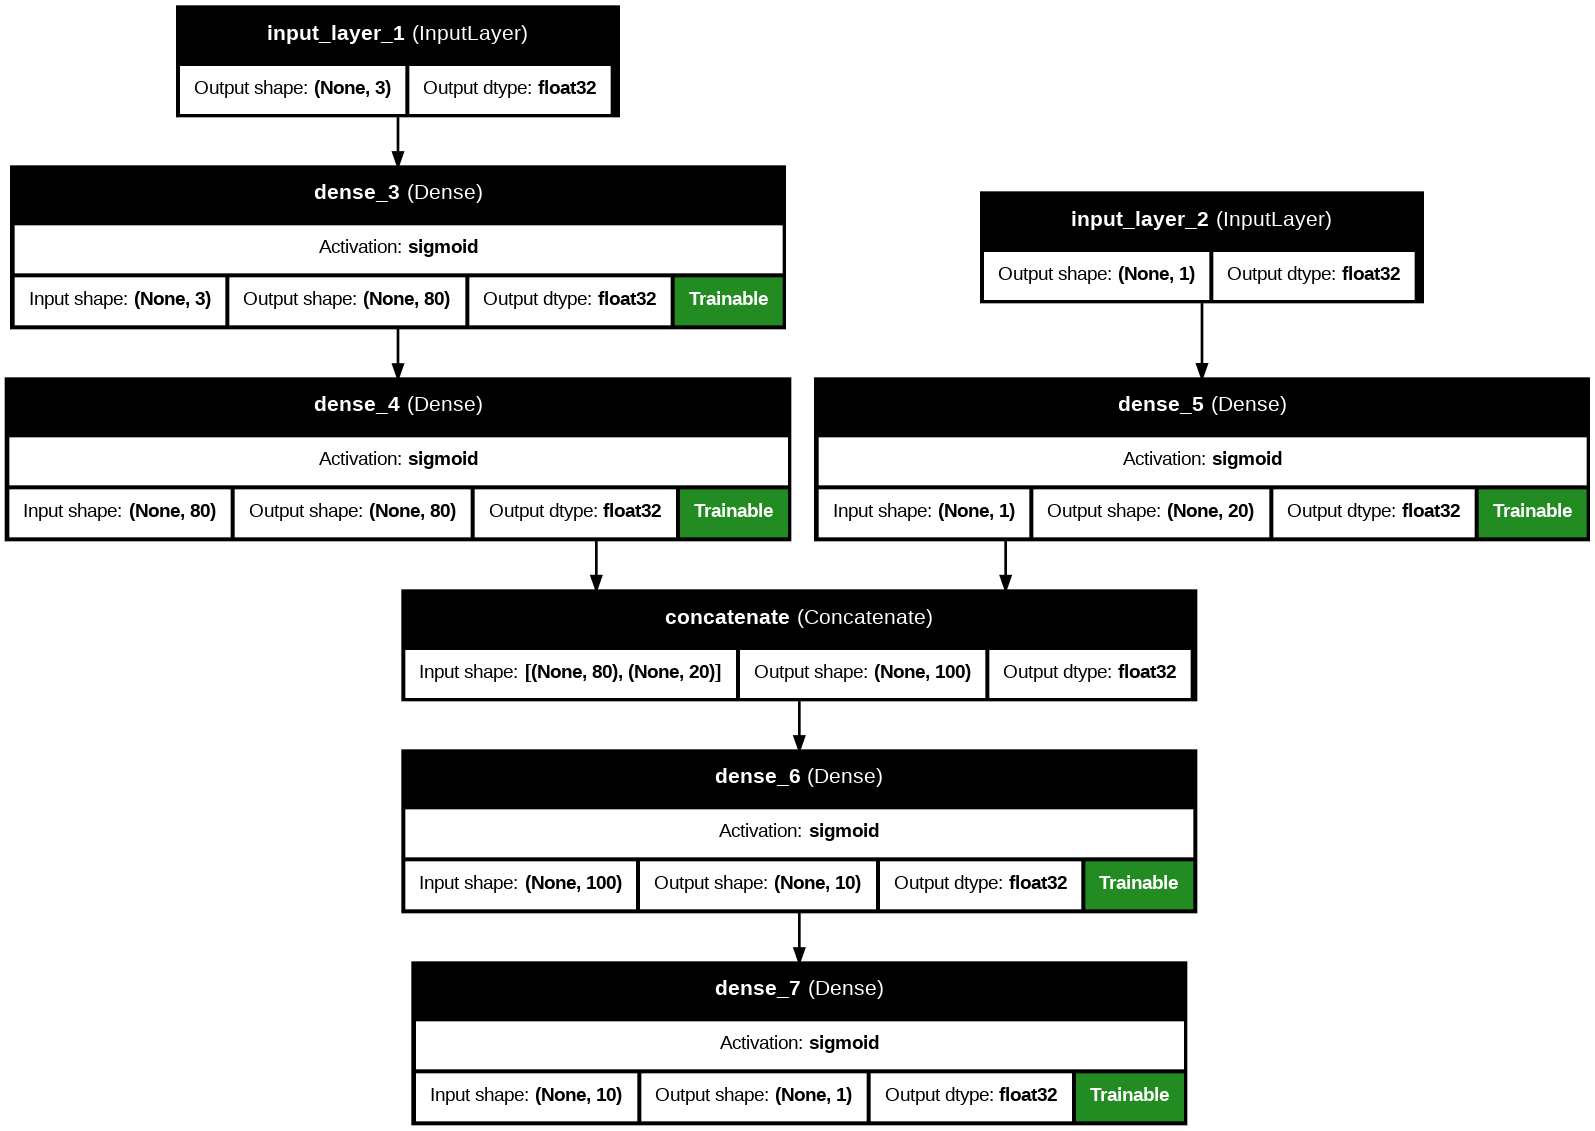

In [ ]:
from IPython.display import display

model.summary()

# Plot a schematics of the model
img=utils.plot_model(model,
                     to_file=network_name_multiinput+'.png',
                     show_shapes=True,
                     show_dtype=True,
                     show_layer_names=True,
                     rankdir='TB', #'TB' = vertical plot; 'LR' = horizontal plot.
                     expand_nested=True,
                     dpi=96,
                     show_layer_activations=True,
                     show_trainable=True
                    )

# Display the image created
display(img)

In [ ]:
optimizer = Adam()
model.compile(optimizer=optimizer,loss='mse',metrics=['mse'])

In [ ]:
print(x_train[:,-1].shape)
history = model.fit([x_train[:,:3],x_train[:,-1]], y_train,
                    batch_size=mini_batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=([x_val[:,:3],x_val[:,-1]], y_val))

model.save(network_name_multiinput)
plot_history(history)

## Results: neural network prediction against true values

./model_2.keras


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 80)        │        320 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 80)        │      6,480 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20)        │         40 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      1,010 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         11 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,585 (92.13 KB)

 Trainable params: 7,861 (30.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,724 (61.43 KB)

938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0029 - mse: 0.0029
1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


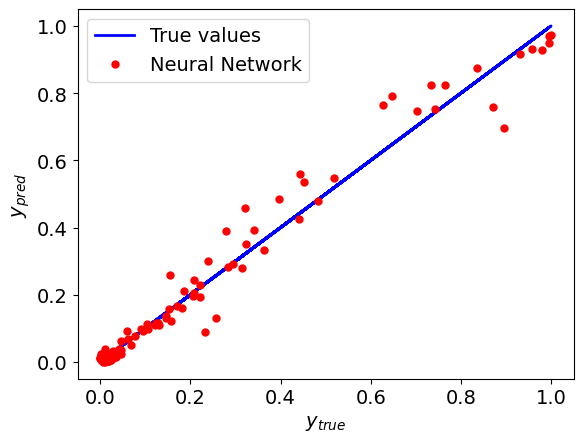

In [ ]:
model=models.load_model(network_name_multiinput)
print(network_name_multiinput)
model.summary()
score = model.evaluate([x_val[:,:3],x_val[:,-1]], y_val, verbose=1)

# Check validation dataset with N random values
N=100
range_rnd=np.random.randint(0,len(x_val),size=(1,N))
y_pred=model.predict([x_val[range_rnd[0],:3],x_val[range_rnd[0],-1]])
y_true=y_val[range_rnd[0]]

# Plot true vs predicted
plt.plot(y_true,y_true, color="blue", fillstyle='none',linewidth=2, marker='.', markersize=0,label='True values')
plt.plot(y_true,y_pred, color="red", linewidth=0, marker='.', markersize=10,label='Neural Network')
plt.xlabel('$y_{true}$')
plt.ylabel('$y_{pred}$')
plt.legend()
plt.show()

## Visualize spectra: neural network prediction against true values

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


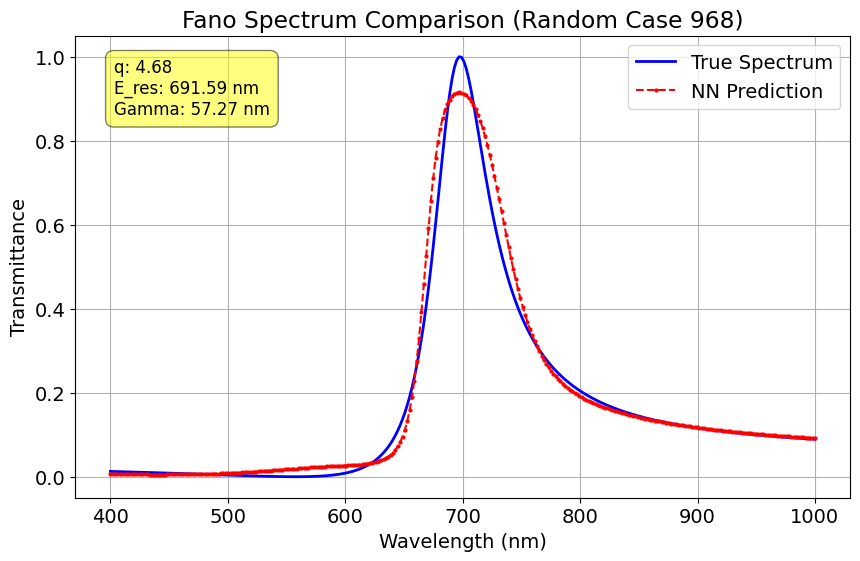

In [ ]:
# Select a random index from the fano_dataset
random_idx = np.random.randint(len(fano_dataset))

# Get the Fano parameters and spectrum for the chosen random case
fano_params_true, spectrum_array_true = fano_dataset[random_idx]
q_true, E_res_true, Gamma_true = fano_params_true
wavelengths_true = spectrum_array_true[:, 0]
transmittance_true = spectrum_array_true[:, 1]

# Prepare input for the neural network prediction
# Repeat Fano parameters for each wavelength in the spectrum
num_wavelengths = len(wavelengths_true)
q_input = np.full(num_wavelengths, q_true)
E_res_input = np.full(num_wavelengths, E_res_true)
Gamma_input = np.full(num_wavelengths, Gamma_true)

# Combine parameters and wavelengths into a raw input array
x_input_raw_single_spectrum = np.column_stack((
    q_input,
    E_res_input,
    Gamma_input,
    wavelengths_true
))

# Normalize the input using the max_values from the entire training dataset
# 'max_values' was computed when creating x_data (cell KuY1rArIBM3j)
x_input_normalized_single_spectrum = x_input_raw_single_spectrum / max_values

# Make a prediction using the trained model
transmittance_pred = model.predict([x_input_normalized_single_spectrum[:,0:3],x_input_normalized_single_spectrum[:,-1]])

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(wavelengths_true, transmittance_true, label='True Spectrum', color='blue', linewidth=2)
plt.plot(wavelengths_true, transmittance_pred, label='NN Prediction', color='red', linestyle='--', marker='.', markersize=4)

plt.title(f'Fano Spectrum Comparison (Random Case {random_idx})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmittance')
plt.legend()
plt.grid(True)

# Display Fano parameters on the figure
plt.text(0.05, 0.95, f'q: {q_true:.2f}\nE_res: {E_res_true:.2f} nm\nGamma: {Gamma_true:.2f} nm',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.show()